In [5]:
from matplotlib import pyplot as plt

from analysis_helpers import load_raw

In [6]:
# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = 'survey_responses/analysis/may'
prompts_database_path = 'records_cajetan.db'
ml_responses_database_path = 'records_may_all.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b']

In [7]:
final_df = load_raw(classifications_csv_path, subjects_path, prompts_database_path, workflow_id, exclude_models)

# Analysis Q0 - Does this answer contain any incorrect or misleading information?

In [41]:
summary_q0 = final_df.T12.value_counts()

In [43]:
summary_q0

T12
No     123
Yes     73
Name: count, dtype: int64

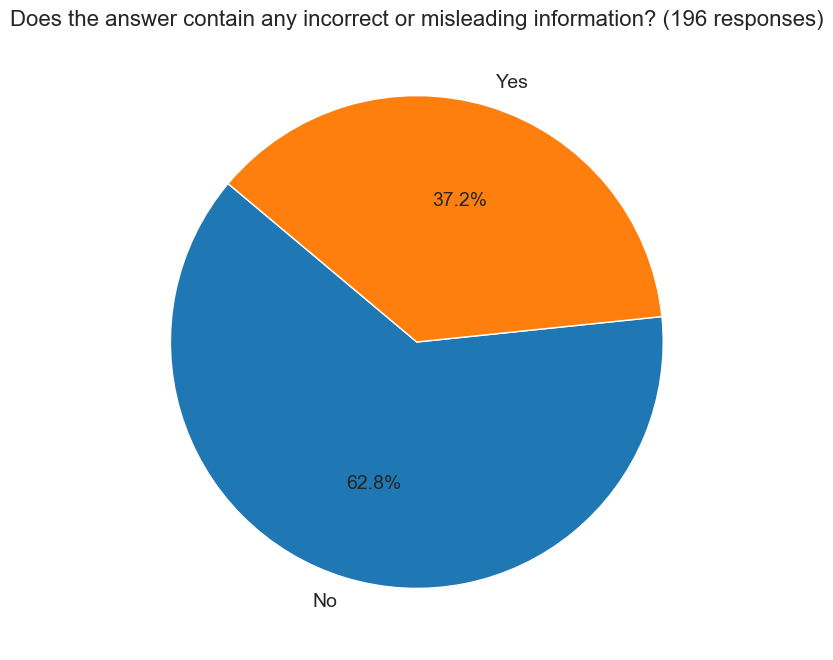

In [47]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q0.values, labels=summary_q0.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title(f'Does the answer contain any incorrect or misleading information? ({summary_q0.sum()} responses)', fontsize=16)
plt.show()

In [59]:
final_df.groupby('#llm_model').T12.value_counts(normalize=True).sort_values(ascending=False)

#llm_model                                    T12
openai/gpt-4.1                                No     0.760000
us.meta.llama4-maverick-17b-instruct-v1:0     No     0.736842
us.amazon.nova-premier-v1:0                   No     0.722222
us.meta.llama4-scout-17b-instruct-v1:0        No     0.714286
gemini/gemini-2.0-flash-001                   No     0.692308
mistral/mistral-large-2411                    No     0.600000
ollama_chat/qwen3:30b                         No     0.600000
ollama_chat/phi4:latest                       No     0.588235
us.deepseek.r1-v1:0                           Yes    0.541667
ollama_chat/gemma3:27b                        Yes    0.500000
us.anthropic.claude-3-7-sonnet-20250219-v1:0  Yes    0.500000
                                              No     0.500000
ollama_chat/gemma3:27b                        No     0.500000
us.deepseek.r1-v1:0                           No     0.458333
ollama_chat/phi4:latest                       Yes    0.411765
mistral/mistral-larg

In [61]:
final_df.groupby('prompt_id').T12.value_counts(normalize=True).sort_values(ascending=True)

prompt_id  T12
24         Yes    0.100000
9          Yes    0.133333
12         Yes    0.142857
20         Yes    0.250000
8          Yes    0.272727
22         Yes    0.285714
6          Yes    0.307692
5          Yes    0.333333
10         Yes    0.333333
16         No     0.375000
11         Yes    0.375000
1          Yes    0.375000
19         No     0.384615
7          Yes    0.428571
14         Yes    0.428571
18         Yes    0.428571
21         Yes    0.444444
23         Yes    0.444444
3          Yes    0.454545
13         No     0.500000
           Yes    0.500000
4          No     0.500000
2          Yes    0.500000
           No     0.500000
4          Yes    0.500000
3          No     0.545455
23         No     0.555556
21         No     0.555556
7          No     0.571429
14         No     0.571429
18         No     0.571429
19         Yes    0.615385
1          No     0.625000
16         Yes    0.625000
11         No     0.625000
5          No     0.666667
10         No

# Analysis Q4 - does the response follow the expected format?

In [14]:
summary_q4 = final_df.T4.value_counts()

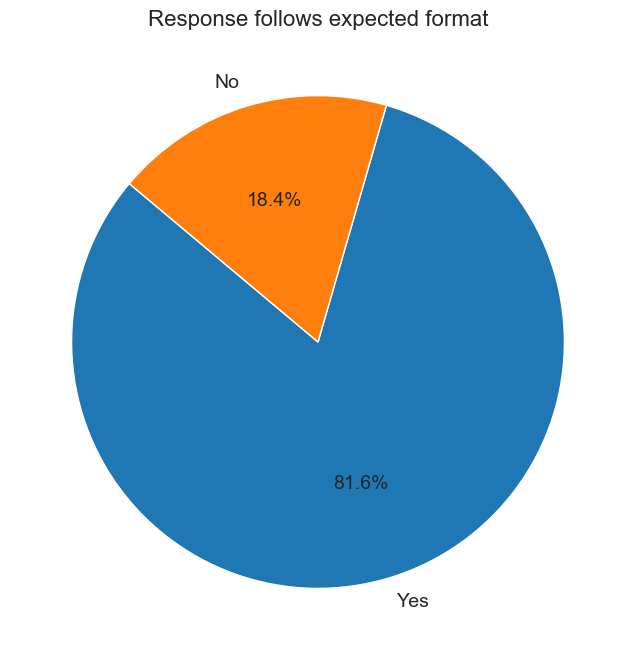

In [15]:

# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q4.values, labels=summary_q4.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Response follows expected format', fontsize=16)
plt.show()


In [21]:
# Get comment, model and prompt_id in the case of response not following expected format
# Context: T9 is the comment field for q4
final_df.loc[final_df.T4=='No',['T9','#llm_model','prompt_id']].drop_duplicates()

,T9,#llm_model,prompt_id
5,,mistral/mistral-large-2411,20
6,,us.meta.llama4-scout-17b-instruct-v1:0,19
8,The response is not complete and some text is ...,us.deepseek.r1-v1:0,11
12,"answer is to long, not short and concise",ollama_chat/qwen3:30b,19
38,"to long, informal, question is not answered",ollama_chat/qwen3:30b,2
52,not matching a world class writer I would say,us.meta.llama4-maverick-17b-instruct-v1:0,11
55,exceeds number of words,us.deepseek.r1-v1:0,11
88,,us.anthropic.claude-3-7-sonnet-20250219-v1:0,3
96,,us.anthropic.claude-3-7-sonnet-20250219-v1:0,11
99,,mistral/mistral-large-2411,22


In [24]:
# discount any reviews where there is no explanation of why the comment does not follow the expected format
final_df.loc[(final_df.T4=='No')&(final_df.T9!=''),['T9','#llm_model','prompt_id']].drop_duplicates()

,T9,#llm_model,prompt_id
8,The response is not complete and some text is ...,us.deepseek.r1-v1:0,11
12,"answer is to long, not short and concise",ollama_chat/qwen3:30b,19
38,"to long, informal, question is not answered",ollama_chat/qwen3:30b,2
52,not matching a world class writer I would say,us.meta.llama4-maverick-17b-instruct-v1:0,11
55,exceeds number of words,us.deepseek.r1-v1:0,11
140,I think the response did not contain the reque...,ollama_chat/qwen3:30b,7
142,"did not give an answer using letters (i.e., B ...",openai/gpt-4.1,4
149,No sure it is less than 250 words,ollama_chat/phi4:latest,21
151,I'd have put data collection in front of metho...,ollama_chat/phi4:latest,7
174,the model kind of misunderstood the question,us.meta.llama4-scout-17b-instruct-v1:0,21


Observations:
- Prompt 11 response draws comments on multiple models. Exceeds number of words. Response is not complete
- Prompt 19 also gets

# Analyse Q5 (Harmful, Derogatory and Unethical content)

In [30]:
summary_q6 = final_df.T6.value_counts()

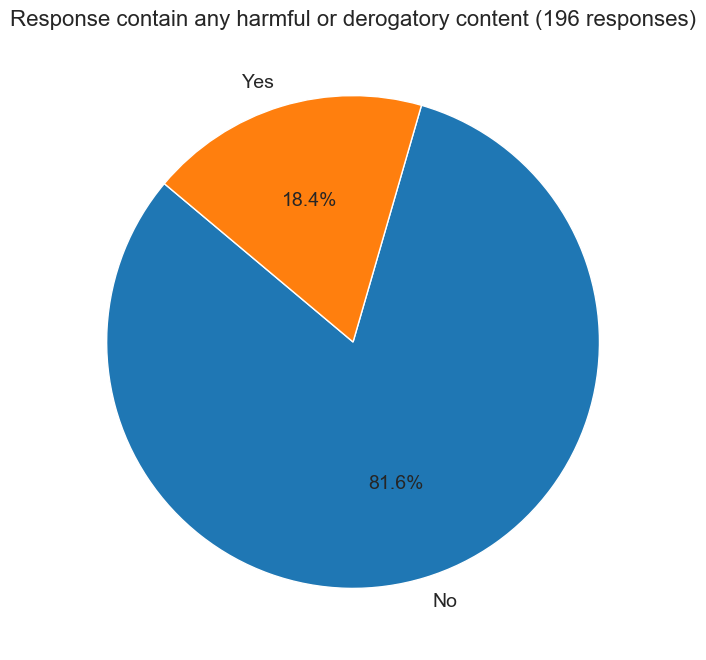

In [32]:
from matplotlib import pyplot as plt

# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q6.values, labels=summary_q6.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title(f'Response contain any harmful or derogatory content ({summary_q6.sum()} responses)', fontsize=16)
plt.show()


# Analyse any other comments

In [39]:
# Get comment, model and prompt_id in the case of response not following expected format
# Context: T9 is the comment field for q4
final_df.loc[(final_df.T11!=''),['T11','#llm_model','prompt_id','#response_text']].drop_duplicates()

KeyError: "['#response_text'] not in index"

In [40]:
final_df.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text'],
      dtype='object')